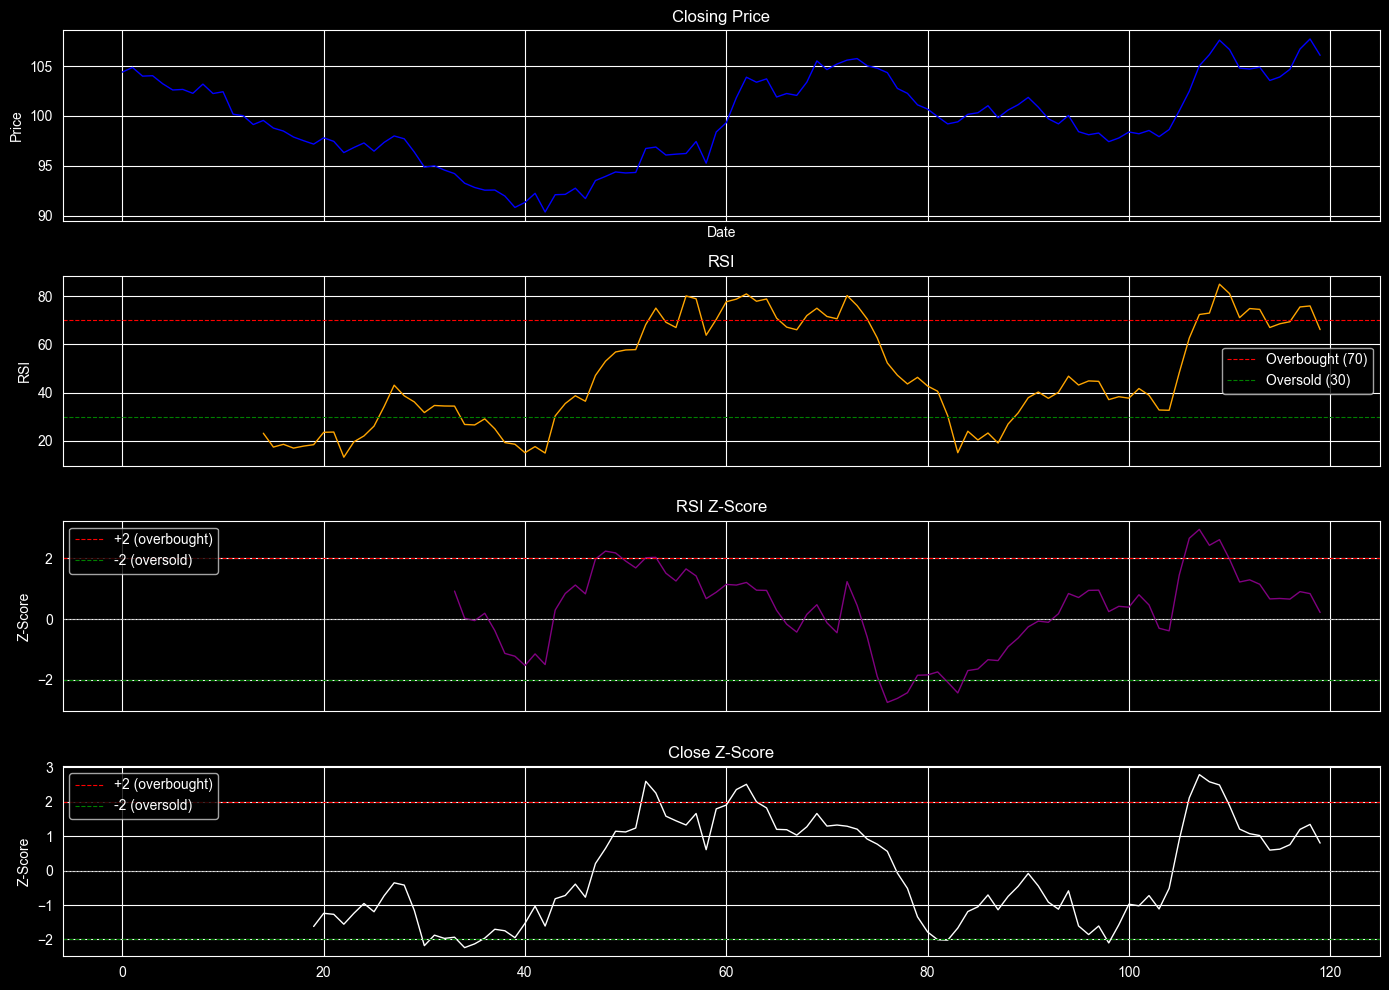

      close    rsi  close_zscore  rsi_zscore
33  94.2196  34.37     -1.934453    0.919618
34  93.2596  26.75     -2.237533    0.025316
35  92.8308  26.55     -2.127780   -0.052145
36  92.5625  29.08     -1.962061    0.190847
37  92.5750  24.94     -1.704045   -0.380225
38  91.9744  19.23     -1.747946   -1.132203
39  90.8315  18.54     -1.948926   -1.224392
40  91.3376  15.03     -1.531372   -1.529456
41  92.2475  17.56     -1.031947   -1.147680
42  90.3738  14.89     -1.610137   -1.498893


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def compute_rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    zscore = (series - rolling_mean) / rolling_std
    return zscore

def add_zscore_features(df: pd.DataFrame, window: int = 20) -> pd.DataFrame:
    df['rsi_zscore'] = compute_rolling_zscore(df['rsi'], window)
    df['close_zscore'] = compute_rolling_zscore(df['close'], window)
    return df

if __name__ == "__main__":
    # load df with OHLCV + RSI already computed
    df = pd.read_csv("../Datasets/mean-reverting_range.csv")

    # call add_zscore_features
    df = add_zscore_features(df)
    # df['date'] = pd.to_datetime(df['date'])

    # Plot RSI vs RSI Z-Score
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    # axes[0].plot(df['date'], df['close'], color='blue', linewidth=1)
    axes[0].plot(df['close'], color='blue', linewidth=1)
    axes[0].set_title('Closing Price')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Price')

    axes[1].plot(df['rsi'], color='orange', linewidth=1)
    axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
    axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
    axes[1].set_title('RSI')
    axes[1].set_ylabel('RSI')
    axes[1].legend()

    axes[2].plot(df['rsi_zscore'], color='purple', linewidth=1)
    axes[2].axhline(2, color='red', linestyle='--', linewidth=0.8, label='+2 (overbought)')
    axes[2].axhline(-2, color='green', linestyle='--', linewidth=0.8, label='-2 (oversold)')
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[2].set_title('RSI Z-Score')
    axes[2].set_ylabel('Z-Score')
    axes[2].legend()

    axes[3].plot(df['close_zscore'], color='white', linewidth=1)
    axes[3].axhline(2, color='red', linestyle='--', linewidth=0.8, label='+2 (overbought)')
    axes[3].axhline(-2, color='green', linestyle='--', linewidth=0.8, label='-2 (oversold)')
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[3].set_title('Close Z-Score')
    axes[3].set_ylabel('Z-Score')
    axes[3].legend()

    plt.tight_layout()
    plt.savefig("images/zscore_plot_mean_reverting.png", dpi=150)
    plt.show()

    # Preview results
    print(df[['close', 'rsi', 'close_zscore', 'rsi_zscore']].dropna().head(10))
    pass